# Maternal & Antenatal Care — Exploratory Analysis in Python

A Python re-implementation of the Excel exploratory analysis of a first-ANC-contact
dataset: **13,088 patient records**, 4 districts, 3 programme phases, 170 recorded fields.

The Excel workbook did the analysis with live formulas. This notebook does the same
analysis with pandas, adds visualisations, and — at the end — **asserts every headline
figure against the values in the workbook** so the two can't silently drift apart.

**Sections**

1. Cohort overview — who is in the data
2. Demographic profile — age, literacy, education
3. Maternal risk & nutrition — BMI, anaemia, the risk-to-referral gap
4. Antenatal screening & service coverage cascade
5. Change across programme phases
6. Geographic hotspots — district comparison
7. Data quality snapshot
8. Validation against the Excel workbook

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA_PATH = Path("data/Maternal & Antenatal Care Dataset_analysis.xlsx")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## Chart style

One style block, applied everywhere, so every figure in the notebook reads as one system:
a near-white chart surface, recessive axes and grid, ink-coloured text (never series-coloured),
and a fixed categorical order so a district keeps its colour in every chart it appears in.

In [2]:
SURFACE = "#FCFCFB"
INK = "#0B0B0B"
INK_2 = "#52514E"
INK_3 = "#8A8880"
GRID = "#E6E5E0"

# Categorical slots, assigned in fixed order and never cycled.
CAT = ["#2A78D6", "#EB6834", "#1BAF7A", "#EDA100"]
# Sequential ramp (one hue, light -> dark) for ordered magnitude.
SEQ = ["#BBD4F2", "#6BA3E3", "#2A78D6", "#12457F"]
# Status colours, reserved — never reused as "series 5".
GOOD, WARN, CRIT = "#1BAF7A", "#EDA100", "#D64545"

mpl.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "figure.dpi": 140,
    "savefig.dpi": 160,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "text.color": INK,
    "axes.labelcolor": INK_2,
    "axes.edgecolor": GRID,
    "axes.linewidth": 1.0,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlecolor": INK,
    "axes.titlepad": 14,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": GRID,
    "grid.linewidth": 0.9,
    "xtick.color": INK_2,
    "ytick.color": INK_2,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.frameon": False,
    "legend.fontsize": 9.5,
})


def finish(ax, xgrid=False, ygrid=False):
    """Strip the chart down to marks + one grid direction."""
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    ax.grid(axis="x", visible=xgrid)
    ax.grid(axis="y", visible=ygrid)
    ax.tick_params(length=0)
    return ax


def pct(x, digits=1):
    return f"{x * 100:.{digits}f}%"


def save(fig, name):
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path)
    print(f"saved {path}")

## Load and prepare

The raw sheet has 170 columns with long, question-text headers (`"28. Was she given a blood
haemoglobin test? (1 - YES, 2 - NO )"`). Rather than typing those, columns are addressed by
**position** — the same positions the Excel sheet referenced by letter — and mapped to short
analysis names. Coded values follow the questionnaire convention `1 = Yes, 2 = No, 9 = Unknown`.

In [3]:
raw = pd.read_excel(DATA_PATH, sheet_name="Raw data")
print(f"{raw.shape[0]:,} rows x {raw.shape[1]} columns")

# position -> short name. Excel letters from the workbook are given for cross-reference.
COLS = {
    2: "district",             # C
    8: "phase",                # I
    12: "anc_contact_date",    # M
    13: "age",                 # N
    18: "literate",            # S
    19: "education",           # T
    23: "lmp_date",            # X
    29: "height_cm",           # AD
    31: "weight_kg",           # AF
    35: "bp_check",            # AJ
    44: "tetanus",             # AS
    48: "blood_typing",        # AW
    51: "hiv_test",            # AZ
    57: "syphilis_test",       # BF
    74: "hep_b_test",          # BW
    81: "urine_test",          # CD
    95: "ogtt",                # CR
    105: "hb_test",            # DB
    108: "anaemia_dx",         # DE
    113: "tb_screen",          # DJ
    118: "malaria_test",       # DO
    131: "folic_acid",         # EB
    132: "ifa",                # EC
    142: "high_risk",          # EM
    144: "referred",           # EO
}

df = pd.DataFrame({name: raw.iloc[:, pos] for pos, name in COLS.items()})

# Two weight cells arrive as datetimes: Excel formatted the numbers 50 and 57.9 as dates, so
# openpyxl hands back 1900-02-19 and 1900-02-26 21:36. Recovering the underlying serial number
# puts both women back in the BMI analysis instead of silently dropping them.
import datetime as _dt

EXCEL_EPOCH = _dt.datetime(1899, 12, 31)


def excel_serial(value):
    if isinstance(value, (_dt.datetime, pd.Timestamp)):
        return (pd.Timestamp(value).to_pydatetime() - EXCEL_EPOCH).total_seconds() / 86400
    return value


df["weight_kg"] = df["weight_kg"].map(excel_serial)

# Numeric coercion: a small number of age cells are non-numeric.
for c in ("age", "height_cm", "weight_kg"):
    df[c] = pd.to_numeric(df[c], errors="coerce")

YES = 1  # questionnaire convention: 1 = Yes, 2 = No, 9 / 99 = Unknown


def is_yes(col):
    return df[col].eq(YES)


DISTRICTS = ["Barpeta", "Nagaon", "Viluppuram", "Virudhunagar"]
DISTRICT_COLOR = dict(zip(DISTRICTS, CAT))

# Phase order is programme chronology, not alphabetical.
# NB: "Prepration" is spelled that way in the source data; kept verbatim as the key.
PHASES = ["Baseline", "Prepration", "Implementation"]
PHASE_LABEL = {"Baseline": "Baseline", "Prepration": "Preparation", "Implementation": "Implementation"}
PHASE_COLOR = dict(zip(PHASES, [SEQ[0], SEQ[1], SEQ[2]]))

df["district"] = pd.Categorical(df["district"], categories=DISTRICTS, ordered=True)
df["phase"] = pd.Categorical(df["phase"], categories=PHASES, ordered=True)

N = len(df)
df.head(3)

13,088 rows x 170 columns


,district,phase,anc_contact_date,age,literate,education,lmp_date,height_cm,weight_kg,bp_check,tetanus,blood_typing,hiv_test,syphilis_test,hep_b_test,urine_test,ogtt,hb_test,anaemia_dx,tb_screen,malaria_test,folic_acid,ifa,high_risk,referred
0,Barpeta,Baseline,2022-05-11,16.0,9.0,99,2022-02-17,156.0,49.0,1,1,2,2,2,2.0,1,2,1,1.0,2.0,2.0,1.0,2.0,1.0,1
1,Barpeta,Baseline,2022-05-11,21.0,9.0,99,2022-03-13,167.0,82.0,1,1,2,2,2,2.0,1,2,1,1.0,2.0,2.0,1.0,2.0,2.0,2
2,Barpeta,Baseline,2022-05-04,24.0,9.0,99,2022-01-10,152.0,43.0,1,1,2,2,2,2.0,1,2,1,1.0,2.0,2.0,1.0,2.0,2.0,2


## 1. Cohort overview

Who is in the dataset, and how the records split across the two axes every later section
cuts by: **district** (geography) and **programme phase** (time).

In [4]:
district_counts = df["district"].value_counts().reindex(DISTRICTS)
phase_counts = df["phase"].value_counts().reindex(PHASES)

overview = pd.DataFrame({
    "Metric": ["Total patient records", "Districts covered", "Programme phases covered"],
    "Value": [N, df["district"].nunique(), df["phase"].nunique()],
})
print(overview.to_string(index=False))
print()
print(pd.DataFrame({"Patients": district_counts, "Share": district_counts / N}).to_string())

                  Metric  Value
   Total patient records  13088
       Districts covered      4
Programme phases covered      3

              Patients     Share
district                        
Barpeta           3436  0.262531
Nagaon            3085  0.235712
Viluppuram        3267  0.249618
Virudhunagar      3300  0.252139


saved figures/01_cohort.png


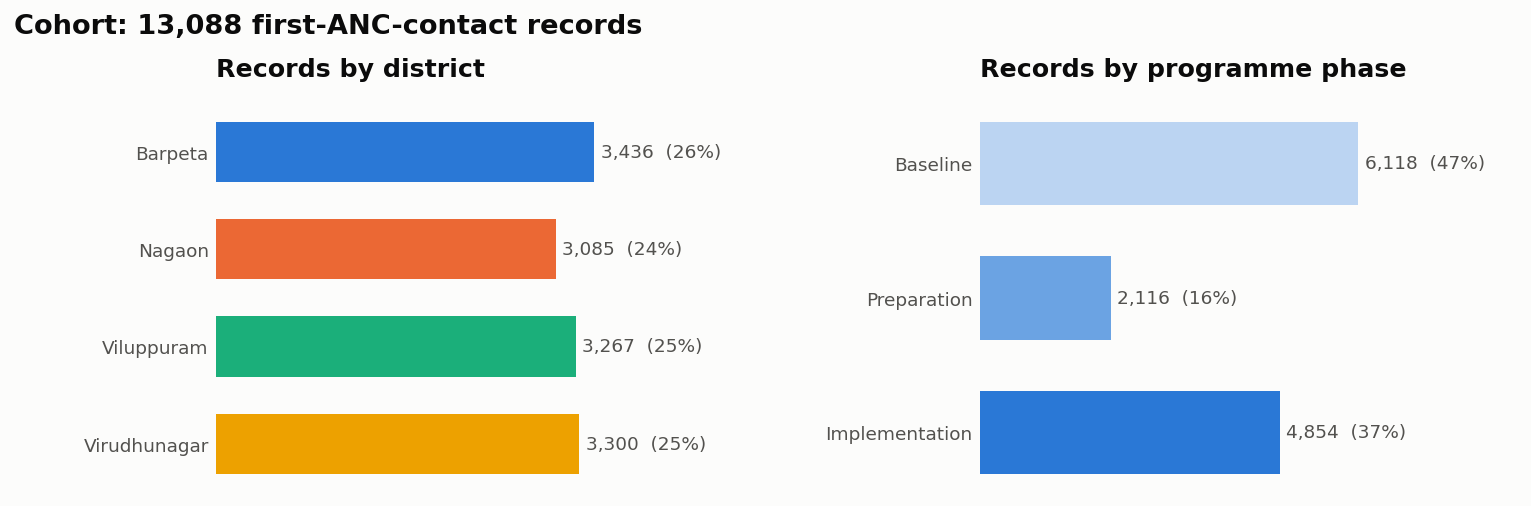

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"wspace": 0.42})

ax = axes[0]
ax.barh(DISTRICTS[::-1], district_counts[::-1].values,
        color=[DISTRICT_COLOR[d] for d in DISTRICTS[::-1]], height=0.62)
for i, d in enumerate(DISTRICTS[::-1]):
    v = district_counts[d]
    ax.text(v + 60, i, f"{v:,}  ({v / N:.0%})", va="center", fontsize=9.5, color=INK_2)
ax.set_xlim(0, district_counts.max() * 1.42)
ax.set_xticks([])
ax.set_title("Records by district", loc="left")
finish(ax)

ax = axes[1]
labels = [PHASE_LABEL[p] for p in PHASES]
ax.barh(labels[::-1], phase_counts[::-1].values,
        color=[PHASE_COLOR[p] for p in PHASES[::-1]], height=0.62)
for i, p in enumerate(PHASES[::-1]):
    v = phase_counts[p]
    ax.text(v + 100, i, f"{v:,}  ({v / N:.0%})", va="center", fontsize=9.5, color=INK_2)
ax.set_xlim(0, phase_counts.max() * 1.42)
ax.set_xticks([])
ax.set_title("Records by programme phase", loc="left")
finish(ax)

fig.suptitle(f"Cohort: {N:,} first-ANC-contact records", x=0.005, ha="left",
             fontsize=14, fontweight="bold", y=1.06)
save(fig, "01_cohort")
plt.show()

The four districts are close to evenly split (23.6%–26.3%), so district comparisons later on
aren't distorted by one dominant site. Phases are not balanced — Baseline is 47% of records —
which matters for section 5: phase comparisons must be **rates**, never counts.

## 2. Demographic profile

Age is the demographic field with real analytic weight here: pregnancy under 20 is itself a
clinical risk factor. Literacy and education are recorded but heavily `Unknown`-coded.

In [6]:
age_bands = pd.cut(df["age"], bins=[0, 19.999, 34.999, 200],
                   labels=["Under 20", "20 - 34", "35 and above"])
age_counts = age_bands.value_counts().reindex(["Under 20", "20 - 34", "35 and above"])
# Denominator is records with a usable age (12,903), not all 13,088 — matching the workbook.
# Against all records the under-20 share is 15.0% rather than 15.2%; either way, ~1 in 7.
age_share = age_counts / age_counts.sum()

literacy = df["literate"].map({1: "Literate", 2: "Not literate", 9: "Unknown"}).fillna("Unknown")
lit_counts = literacy.value_counts().reindex(["Literate", "Not literate", "Unknown"])

edu = df["education"].map({1: "None", 2: "Primary", 3: "Secondary", 4: "Higher"}).fillna("Unknown")
edu_counts = edu.value_counts().reindex(["None", "Primary", "Secondary", "Higher", "Unknown"])

print(pd.DataFrame({"Patients": age_counts, "Share": age_share}).to_string())
print(f"\nAge recorded for {df['age'].notna().sum():,} of {N:,} records "
      f"(median {df['age'].median():.0f}, IQR {df['age'].quantile(.25):.0f}-{df['age'].quantile(.75):.0f})")

              Patients     Share
age                             
Under 20          1967  0.151658
20 - 34          10636  0.820046
35 and above       367  0.028296

Age recorded for 12,970 of 13,088 records (median 24, IQR 21-27)


saved figures/02_demographics.png


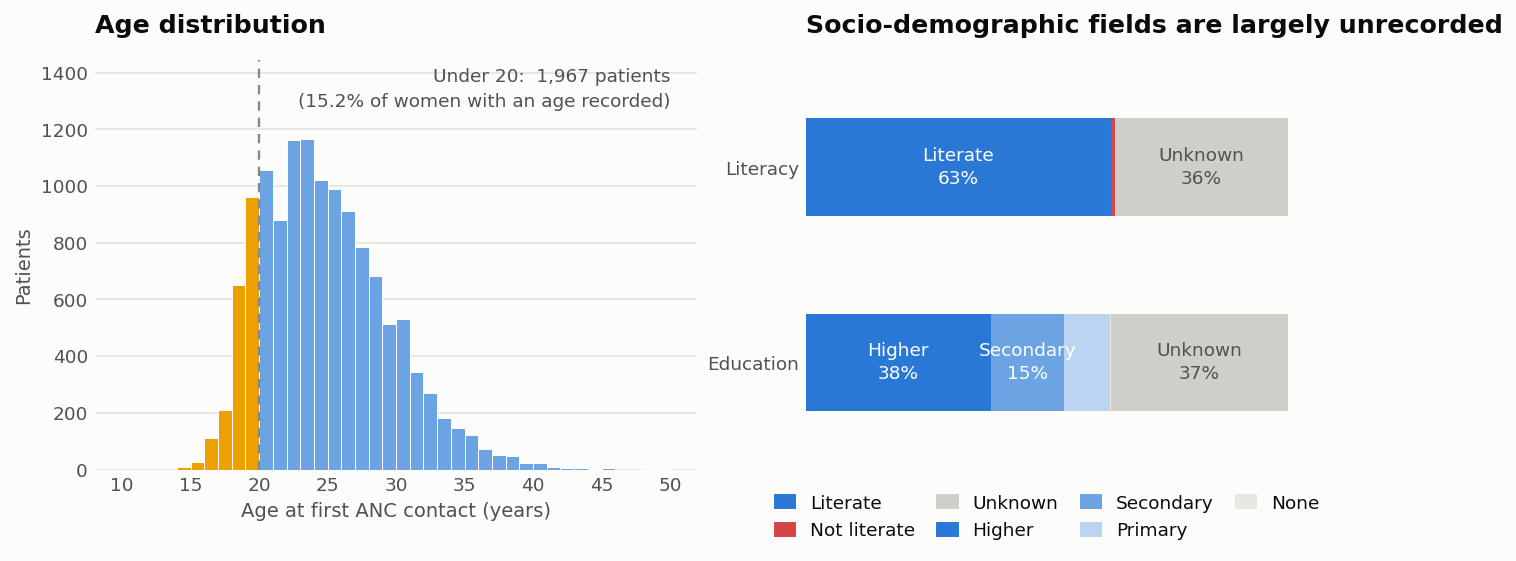

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.25, 1]})

# Age distribution: a histogram shows the shape; the risk band is what the reader needs.
ax = axes[0]
ages = df["age"].dropna()
ax.hist(ages[ages >= 20], bins=np.arange(10, 51, 1), color=SEQ[1], edgecolor=SURFACE, linewidth=0.5)
ax.hist(ages[ages < 20], bins=np.arange(10, 51, 1), color=WARN, edgecolor=SURFACE, linewidth=0.5)
ax.axvline(20, color=INK_3, linewidth=1.2, linestyle=(0, (4, 3)))
ax.set_ylim(0, ax.get_ylim()[1] * 1.18)
ax.annotate(f"Under 20:  {age_counts['Under 20']:,} patients\n({age_share['Under 20']:.1%} of women with an age recorded)",
            xy=(50, ax.get_ylim()[1] * 0.98), ha="right", va="top",
            fontsize=9.5, color=INK_2, linespacing=1.5)
ax.set_xlabel("Age at first ANC contact (years)")
ax.set_ylabel("Patients")
ax.set_title("Age distribution", loc="left")
finish(ax, ygrid=True)

# Literacy / education: the story is the size of the Unknown block, so plot that honestly.
# A segment is labelled in place only when it is wide enough to hold the text; the legend
# carries the rest, so nothing is identified by colour alone.
ax = axes[1]
UNKNOWN_GREY = "#CFCEC8"
rows = [
    (1, ["Literate", "Not literate", "Unknown"], [SEQ[2], CRIT, UNKNOWN_GREY], lit_counts),
    (0, ["Higher", "Secondary", "Primary", "None", "Unknown"],
     [SEQ[2], SEQ[1], SEQ[0], "#E8E7E2", UNKNOWN_GREY], edu_counts),
]
handles = {}
for y, cats, colors, counts in rows:
    left = 0.0
    for c, col in zip(cats, colors):
        v = counts[c] / N
        ax.barh([y], [v], left=left, color=col, height=0.5)
        handles.setdefault(c, mpl.patches.Patch(color=col, label=c))
        if v > 0.14:
            ax.text(left + v / 2, y, f"{c}\n{v:.0%}", ha="center", va="center", fontsize=9.5,
                    color="white" if col in (SEQ[2], SEQ[1], CRIT) else INK_2, linespacing=1.4)
        left += v

ax.set_yticks([0, 1], ["Education", "Literacy"])
ax.set_xticks([])
ax.set_xlim(0, 1)
ax.set_ylim(-0.55, 1.55)
ax.set_title("Socio-demographic fields are largely unrecorded", loc="left")
ax.legend(handles=list(handles.values()), loc="upper center", bbox_to_anchor=(0.5, -0.02),
          ncols=4, columnspacing=1.2, handlelength=1.1)
finish(ax)

save(fig, "02_demographics")
plt.show()

**~15% of patients are under 20** — roughly one in seven, and a group that carries elevated
obstetric risk on its own. The right-hand chart is the caveat that governs the rest of the
analysis: about a third of literacy and education values are `Unknown`, so no socio-economic
conclusion from this dataset is safe.

## 3. Maternal risk & nutrition

Three risk lenses: body mass index, anaemia burden, and — the one with an operational
consequence — whether women flagged high-risk were actually referred onward.

In [8]:
bmi = df["weight_kg"] / (df["height_cm"] / 100) ** 2
# Cut-points follow the workbook's helper column: <18.5 / 18.5-24.9 / >24.9.
# Note this is the workbook's convention, not WHO's: WHO puts overweight at >=25.0, which would
# move ~77 records from Overweight back to Normal. Kept as-is so the two analyses reconcile.
bmi_cat = pd.cut(bmi, bins=[0, 18.5, 24.9, np.inf], right=False,
                 labels=["Underweight", "Normal", "Overweight"])
# Two values are physiologically implausible (BMI 9.7 and 68.3) — kept in, since the workbook
# keeps them, but they are a data-entry flag rather than a finding.
bmi_counts = bmi_cat.value_counts().reindex(["Underweight", "Normal", "Overweight"])
bmi_share = bmi_counts / bmi_counts.sum()
print(pd.DataFrame({"Patients": bmi_counts, "Share of BMI-assessed": bmi_share}).to_string())

anaemia = (
    df.assign(tested=is_yes("hb_test"), anaemic=is_yes("anaemia_dx"))
      .groupby("district", observed=True)
      .agg(tested=("tested", "sum"), anaemic=("anaemic", "sum"))
)
anaemia["rate"] = anaemia["anaemic"] / anaemia["tested"]
overall_anaemia = anaemia["anaemic"].sum() / anaemia["tested"].sum()
print()
print(anaemia.to_string())
print(f"Overall anaemia rate (of tested): {overall_anaemia:.1%}")

hr = is_yes("high_risk")
ref = is_yes("referred")
risk_table = pd.crosstab(hr.map({True: "Identified high risk", False: "Not high risk"}),
                         ref.map({True: "Referred", False: "Not referred"}))
hr_referral_rate = (hr & ref).sum() / hr.sum()
print()
print(risk_table.to_string())
print(f"% of high-risk women referred: {hr_referral_rate:.1%}")

             Patients  Share of BMI-assessed
Underweight      2921               0.230272
Normal           7036               0.554671
Overweight       2728               0.215057



              tested  anaemic      rate
district                               
Barpeta         3168     1055  0.333018
Nagaon          2288      548  0.239510
Viluppuram      3058      226  0.073905
Virudhunagar    3227      468  0.145026
Overall anaemia rate (of tested): 19.6%

referred              Not referred  Referred
high_risk                                   
Identified high risk          2051      1382
Not high risk                 9473       182
% of high-risk women referred: 40.3%


saved figures/03_risk.png


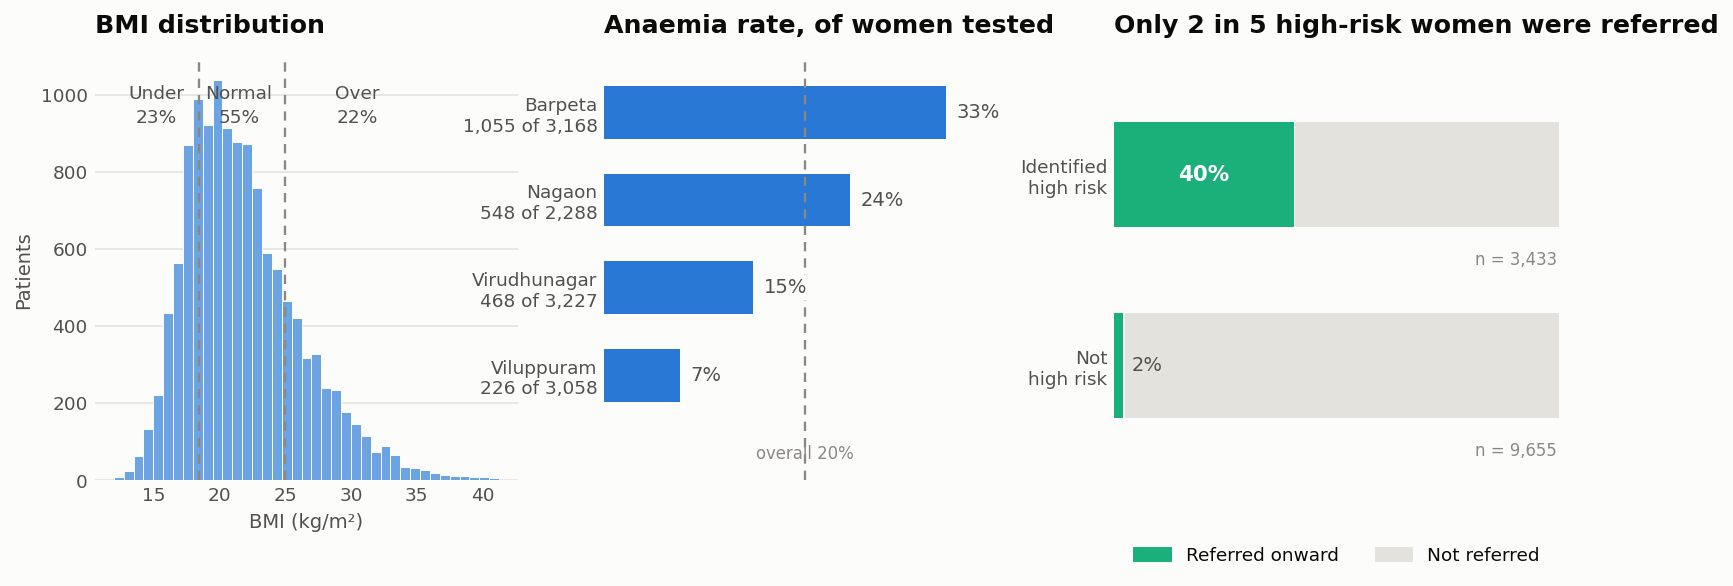

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9), gridspec_kw={"width_ratios": [1, 1, 1.05]})

# BMI — the distribution, with the clinical thresholds marked.
ax = axes[0]
ax.hist(bmi.dropna(), bins=np.arange(12, 42, 0.75), color=SEQ[1],
        edgecolor=SURFACE, linewidth=0.5)
for t in (18.5, 25):
    ax.axvline(t, color=INK_3, linewidth=1.2, linestyle=(0, (4, 3)))
ymax = ax.get_ylim()[1]
for x, label, share in [(15.2, "Under", bmi_share["Underweight"]),
                        (21.5, "Normal", bmi_share["Normal"]),
                        (30.5, "Over", bmi_share["Overweight"])]:
    ax.text(x, ymax * 0.94, f"{label}\n{share:.0%}", ha="center", va="top",
            fontsize=9.5, color=INK_2, linespacing=1.4)
ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Patients")
ax.set_title("BMI distribution", loc="left")
finish(ax, ygrid=True)

# Anaemia — magnitude by district, one hue, ordered.
ax = axes[1]
a = anaemia.sort_values("rate", ascending=True)
ax.barh(range(len(a)), a["rate"].values, color=SEQ[2], height=0.6)
# Counts live in the tick label, where they can't overrun a short bar.
ax.set_yticks(range(len(a)),
              [f"{name}\n{int(r.anaemic):,} of {int(r.tested):,}" for name, r in a.iterrows()])
for i, (_, row) in enumerate(a.iterrows()):
    ax.text(row["rate"] + 0.01, i, f"{row['rate']:.0%}", va="center", fontsize=10, color=INK_2,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1.5))
ax.axvline(overall_anaemia, color=INK_3, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(overall_anaemia, -0.95, f"overall {overall_anaemia:.0%}", ha="center",
        fontsize=8.5, color=INK_3)
ax.set_xlim(0, a["rate"].max() * 1.24)
ax.set_ylim(-1.2, len(a) - 0.4)
ax.set_xticks([])
ax.set_title("Anaemia rate, of women tested", loc="left")
finish(ax)

# The risk-to-action gap — the chart the section exists for.
ax = axes[2]
rows = [("Not\nhigh risk", int(risk_table.loc["Not high risk", "Referred"]),
         int(risk_table.loc["Not high risk", "Not referred"])),
        ("Identified\nhigh risk", int(risk_table.loc["Identified high risk", "Referred"]),
         int(risk_table.loc["Identified high risk", "Not referred"]))]
for i, (label, referred, not_referred) in enumerate(rows):
    total = referred + not_referred
    share = referred / total
    ax.barh([i], [share], color=GOOD, height=0.55)
    ax.barh([i], [1 - share], left=share + 0.004, color="#E3E2DD", height=0.55)
    # Label inside the green segment only when it fits; otherwise just outside it.
    if share > 0.12:
        ax.text(share / 2, i, f"{share:.0%}", ha="center", va="center",
                fontsize=11, color="white", fontweight="bold")
    else:
        ax.text(share + 0.02, i, f"{share:.0%}", va="center", fontsize=10, color=INK_2)
    ax.text(0.995, i - 0.40, f"n = {total:,}", ha="right", va="top", fontsize=8.5, color=INK_3)
ax.set_yticks([0, 1], [r[0] for r in rows])
ax.set_xlim(0, 1)
ax.set_ylim(-0.6, 1.6)
ax.set_xticks([])
ax.legend(handles=[mpl.patches.Patch(color=GOOD, label="Referred onward"),
                   mpl.patches.Patch(color="#E3E2DD", label="Not referred")],
          loc="lower center", bbox_to_anchor=(0.5, -0.24), ncols=2)
ax.set_title("Only 2 in 5 high-risk women were referred", loc="left")
finish(ax)

save(fig, "03_risk")
plt.show()

The middle chart and the right-hand chart are the two findings worth acting on.
**Barpeta's anaemia rate (33%) is 4.5× Viluppuram's (7%)** — a spread that large across four
districts is more likely to be a difference in testing threshold or recording practice than a
genuine 4.5× difference in disease, and is worth checking before it is used to allocate anything.

The right-hand chart is the operational gap: of 3,433 women flagged high-risk, **2,051 have no
recorded referral**. Identification without follow-through is the clearest place where this
programme loses value.

## 4. Antenatal screening & service coverage cascade

Share of all 13,088 patients with each service recorded as delivered. Sorted by coverage,
so the cascade — and where it falls off a cliff — is the shape of the chart.

In [10]:
SERVICES = {
    "Blood pressure check": "bp_check",
    "Tetanus immunization": "tetanus",
    "Blood haemoglobin test": "hb_test",
    "Urine test": "urine_test",
    "Folic acid (FA)": "folic_acid",
    "HIV test": "hiv_test",
    "Syphilis test": "syphilis_test",
    "Blood typing": "blood_typing",
    "Hepatitis B test": "hep_b_test",
    "OGTT (diabetes)": "ogtt",
    "Iron + Folic Acid (IFA)": "ifa",
    "Malaria test": "malaria_test",
    "TB screening": "tb_screen",
}
coverage = pd.Series({label: is_yes(col).sum() for label, col in SERVICES.items()})
coverage_pct = (coverage / N).sort_values()
print(pd.DataFrame({"Patients covered": coverage.reindex(coverage_pct.index[::-1]),
                    "Coverage": coverage_pct[::-1]}).to_string())

                         Patients covered  Coverage
Blood pressure check                12761  0.975015
Tetanus immunization                11832  0.904034
Blood haemoglobin test              11741  0.897081
Urine test                          10117  0.772998
Folic acid (FA)                      9237  0.705761
HIV test                             8054  0.615373
Syphilis test                        8044  0.614609
Blood typing                         7336  0.560513
Hepatitis B test                     5115  0.390816
OGTT (diabetes)                      1918  0.146546
Iron + Folic Acid (IFA)              1168  0.089242
Malaria test                          334  0.025520
TB screening                          165  0.012607


saved figures/04_coverage_cascade.png


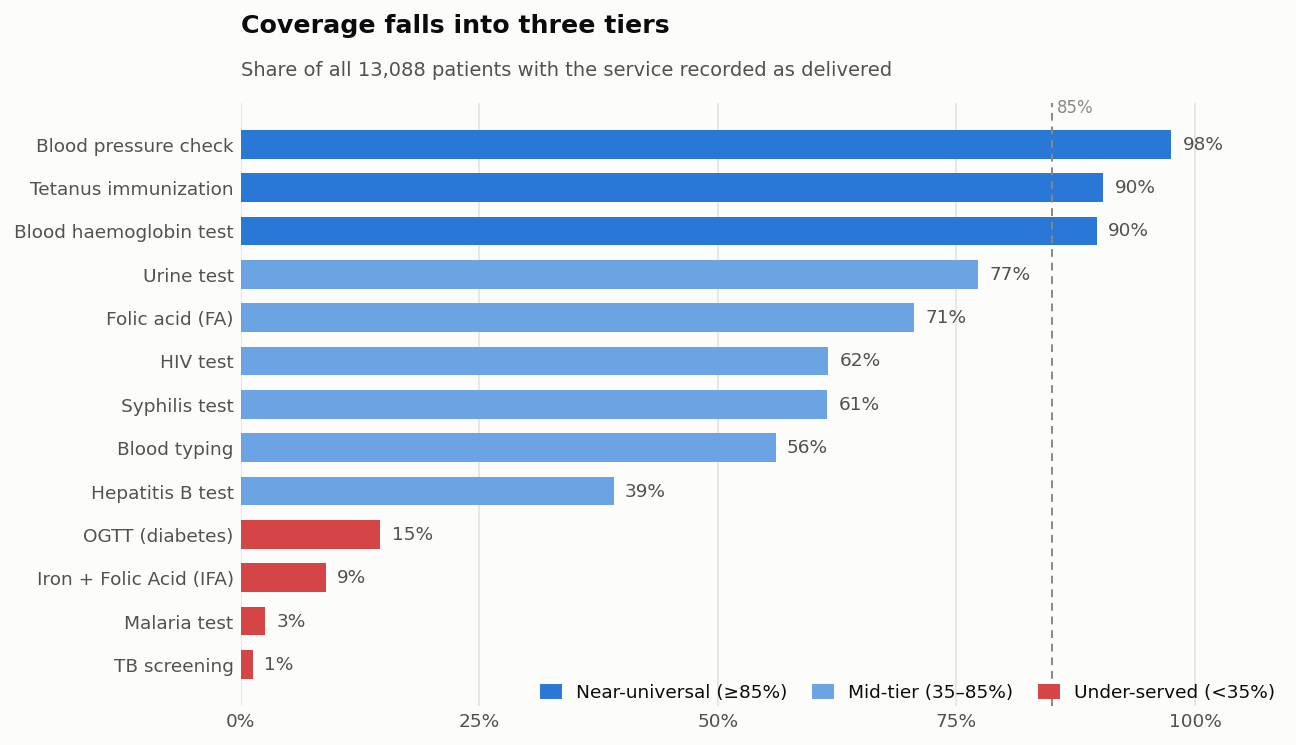

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
vals = coverage_pct.values
# Magnitude -> one hue, stepped by tier. Tiers are a real feature of the data, not decoration.
tier_color = [SEQ[2] if v >= 0.85 else (SEQ[1] if v >= 0.35 else CRIT) for v in vals]
ax.barh(range(len(vals)), vals, color=tier_color, height=0.66)
ax.set_yticks(range(len(vals)), coverage_pct.index.tolist())
for i, v in enumerate(vals):
    ax.text(v + 0.012, i, f"{v:.0%}", va="center", fontsize=9.5, color=INK_2)
ax.set_xlim(0, 1.08)
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.axvline(0.85, color=INK_3, linewidth=1, linestyle=(0, (4, 3)))
ax.text(0.855, len(vals) - 0.35, "85%", fontsize=8.5, color=INK_3, va="bottom")
ax.set_title("Coverage falls into three tiers", loc="left", pad=36)
ax.text(0, 1.045, f"Share of all {N:,} patients with the service recorded as delivered",
        transform=ax.transAxes, fontsize=10, color=INK_2)
ax.legend(handles=[mpl.patches.Patch(color=SEQ[2], label="Near-universal (≥85%)"),
                   mpl.patches.Patch(color=SEQ[1], label="Mid-tier (35–85%)"),
                   mpl.patches.Patch(color=CRIT, label="Under-served (<35%)")],
          loc="lower right", bbox_to_anchor=(1.02, -0.02), ncols=3, columnspacing=1.4,
          handlelength=1.1)
finish(ax, xgrid=True)
save(fig, "04_coverage_cascade")
plt.show()

Basic ANC contact is close to universal — blood pressure 98%, tetanus 90%, haemoglobin 90%.
The disease screens sit in a middle band around 40–77%. Then it collapses: **OGTT 15%,
malaria 2.6%, TB 1.3%.** Whether that last tier is under-delivery or under-recording is the
first question to put to the programme; the dataset alone cannot separate the two.

## 5. Change across programme phases

All four indicators are percentages on the same 0–100 scale, so they belong on **one axis in
one chart** — no second y-axis, no indexing. Baseline → Preparation → Implementation.

In [12]:
INDICATORS = {
    "HIV test coverage": "hiv_test",
    "Syphilis test coverage": "syphilis_test",
    "Hb test coverage": "hb_test",
    "High-risk identification": "high_risk",
}
phase_trend = pd.DataFrame({
    label: df.assign(v=is_yes(col)).groupby("phase", observed=True)["v"].mean().reindex(PHASES)
    for label, col in INDICATORS.items()
})
print((phase_trend * 100).round(1).rename(index=PHASE_LABEL).to_string())

                HIV test coverage  Syphilis test coverage  Hb test coverage  High-risk identification
phase                                                                                                
Baseline                     49.4                    49.3              83.0                      24.1
Preparation                  60.5                    59.7              92.1                      28.9
Implementation               77.3                    77.6              97.2                      27.7


saved figures/05_phase_trend.png


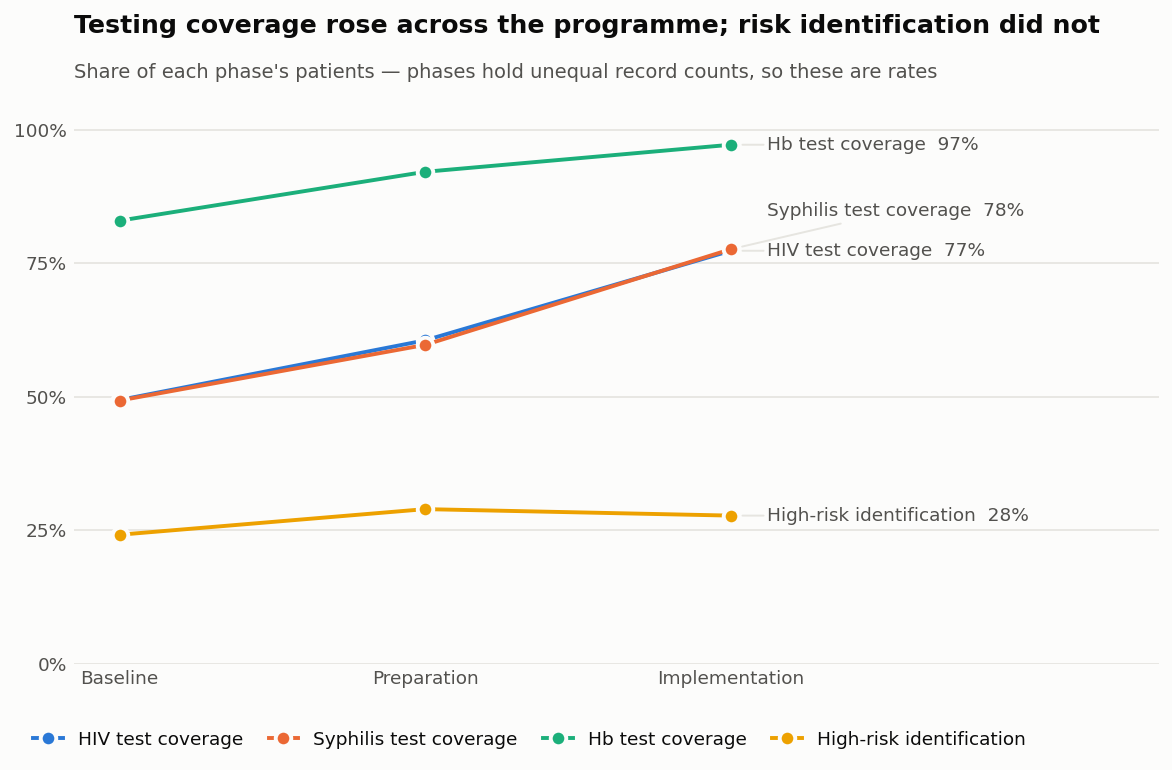

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(3)

# Direct labels are nudged apart where two series land on top of each other
# (HIV 77.3% and syphilis 77.6% are within half a point at Implementation).
ends = sorted(((s.values[-1], i, label) for i, (label, s) in enumerate(phase_trend.items())))
label_y, last = {}, -np.inf
for value, i, label in ends:
    y = max(value, last + 0.075)
    label_y[label] = y
    last = y

for i, (label, series) in enumerate(phase_trend.items()):
    ax.plot(x, series.values, color=CAT[i], linewidth=2, marker="o", markersize=8,
            markeredgecolor=SURFACE, markeredgewidth=2, label=label, zorder=3)
    ax.annotate(f"{label}  {series.values[-1]:.0%}",
                xy=(2.0, series.values[-1]), xytext=(2.12, label_y[label]),
                va="center", fontsize=9.5, color=INK_2,
                arrowprops=dict(arrowstyle="-", color=GRID, linewidth=1,
                                shrinkA=0, shrinkB=6))

ax.set_xticks(x, [PHASE_LABEL[p] for p in PHASES])
ax.set_xlim(-0.15, 3.4)
ax.set_ylim(0, 1.05)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0], ["0%", "25%", "50%", "75%", "100%"])
ax.set_title("Testing coverage rose across the programme; risk identification did not",
             loc="left", pad=36)
ax.text(0, 1.045, "Share of each phase's patients — phases hold unequal record counts, so these are rates",
        transform=ax.transAxes, fontsize=10, color=INK_2)
ax.legend(loc="upper center", bbox_to_anchor=(0.42, -0.09), ncols=4, columnspacing=1.4,
          handlelength=1.6)
finish(ax, ygrid=True)
save(fig, "05_phase_trend")
plt.show()

**HIV testing climbs from 49% to 77%** and haemoglobin testing from 83% to 97% — the clearest
programme effect in the dataset. High-risk identification, by contrast, is flat near 25–29%:
the programme got better at *testing*, not at *flagging*. This is observational, phase-over-phase
data with no control group, so it shows association with the programme period — not proof the
programme caused it.

## 6. Geographic hotspots

Four indicators, four districts, one panel each. Districts keep the colour they were assigned
in section 1, so the reader tracks a district across panels without re-reading a legend.

In [14]:
by_district = pd.DataFrame({
    "Teen pregnancy": df.assign(v=age_bands.eq("Under 20")).groupby("district", observed=True)["v"].mean(),
    "Anaemia (of tested)": anaemia["rate"],
    "High-risk identified": df.assign(v=is_yes("high_risk")).groupby("district", observed=True)["v"].mean(),
    "Referred onward": df.assign(v=is_yes("referred")).groupby("district", observed=True)["v"].mean(),
}).reindex(DISTRICTS)
print((by_district * 100).round(1).to_string())

              Teen pregnancy  Anaemia (of tested)  High-risk identified  Referred onward
district                                                                                
Barpeta                 26.9                 33.3                  17.9             17.8
Nagaon                  14.6                 24.0                   1.2              6.2
Viluppuram               8.1                  7.4                  37.8             12.8
Virudhunagar             9.9                 14.5                  46.8             10.4


saved figures/06_districts.png


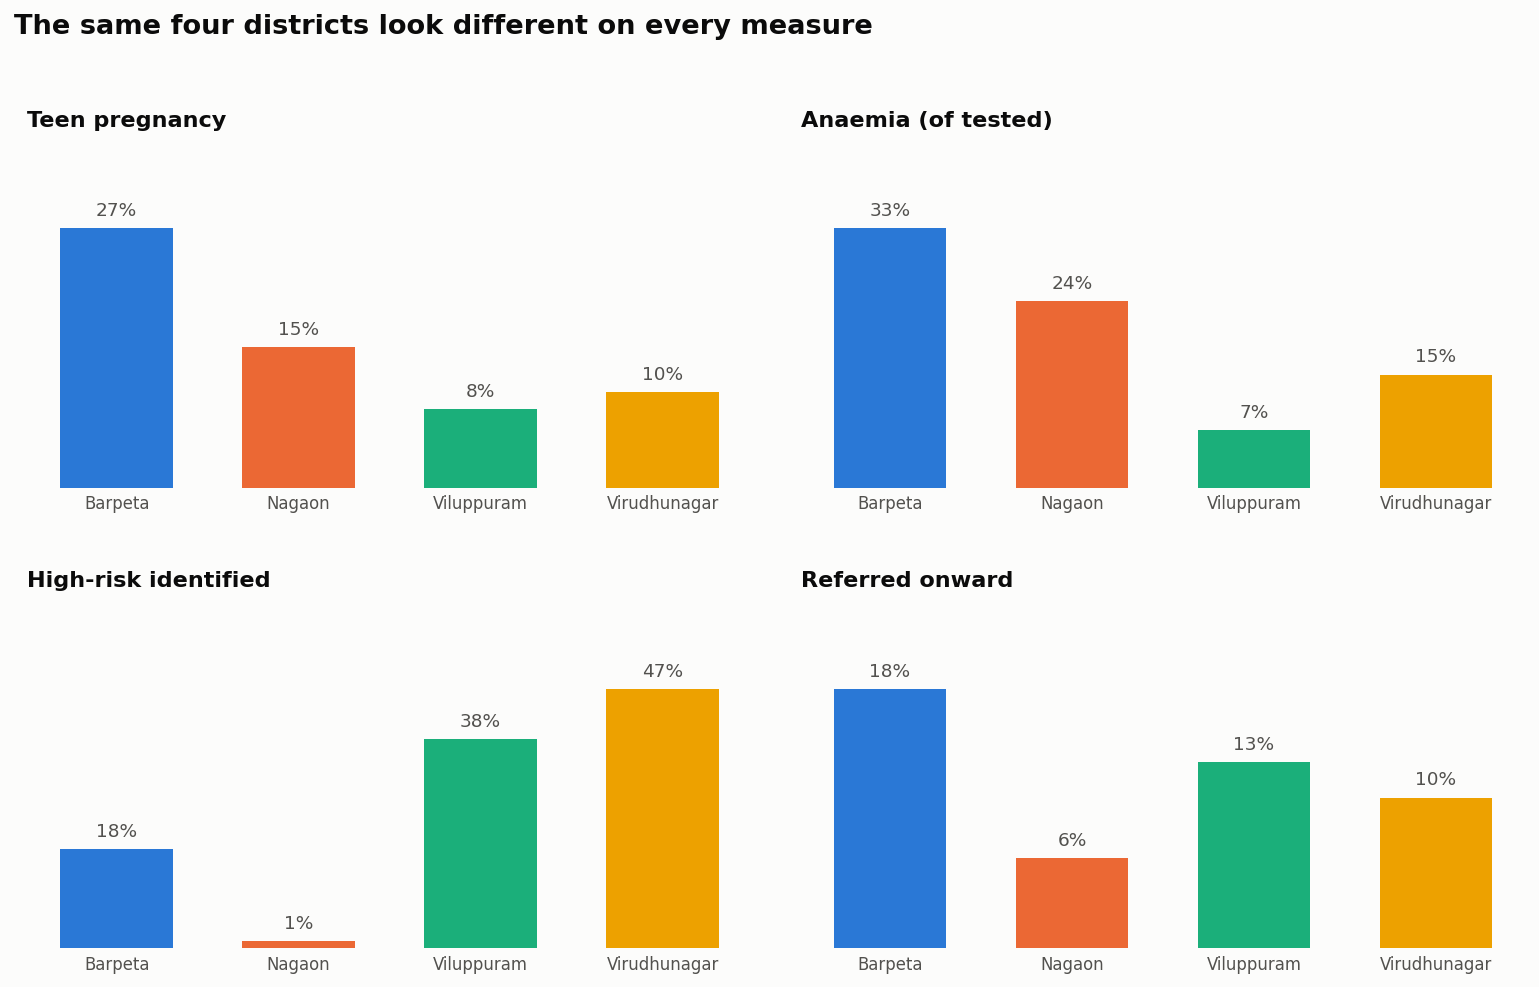

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.8))
for ax, (label, series) in zip(axes.ravel(), by_district.items()):
    ax.bar(range(4), series.values, color=[DISTRICT_COLOR[d] for d in DISTRICTS], width=0.62)
    for i, v in enumerate(series.values):
        ax.text(i, v + series.max() * 0.05, f"{v:.0%}", ha="center", fontsize=9.5, color=INK_2)
    ax.set_xticks(range(4), DISTRICTS, fontsize=8.5)
    ax.set_ylim(0, series.max() * 1.32)
    ax.set_yticks([])
    ax.set_title(label, loc="left", fontsize=11.5, pad=10)
    finish(ax)
fig.suptitle("The same four districts look different on every measure", x=0.005, ha="left",
             fontsize=14, fontweight="bold", y=1.03)
fig.tight_layout(h_pad=3.0, w_pad=2.5)
save(fig, "06_districts")
plt.show()

There is no single "worst" district — which is the finding. Barpeta carries the teen-pregnancy
and anaemia burden; Virudhunagar and Viluppuram flag three to four times as many women as
high-risk but refer fewer of them onward. A uniform national intervention would be aimed at
the wrong problem in at least two of these four districts.

## 7. Data quality snapshot

Four completeness and consistency checks. This is a table, not a chart — four scalars have no
shape worth plotting.

In [16]:
invalid_dates = (df["anc_contact_date"] < df["lmp_date"]).sum()
missing_bmi = (raw.iloc[:, 29].isna() | raw.iloc[:, 31].isna()).sum()  # blank in the source
# Education carries two unknown codes, 9 (7 records) and 99 (4,816); literacy uses 9, plus 5
# blanks. Both are counted as unknown here, which is why these run a few records above the
# workbook's figures of 4,816 and 4,694 — the workbook counted only the dominant code.
edu_unknown = int((~df["education"].isin([1, 2, 3, 4])).sum())
lit_unknown = int((~df["literate"].isin([1, 2])).sum())

quality = pd.DataFrame({
    "Check": [
        "ANC contact date earlier than LMP date (logically invalid)",
        "Missing height or weight (BMI not calculable)",
        "Education level coded 'Unknown'",
        "Literacy coded 'Unknown'",
    ],
    "Records": [invalid_dates, missing_bmi, edu_unknown, lit_unknown],
})
quality["Share"] = (quality["Records"] / N).map(lambda v: f"{v:.1%}")
print(quality.to_string(index=False))

                                                     Check  Records Share
ANC contact date earlier than LMP date (logically invalid)       31  0.2%
             Missing height or weight (BMI not calculable)      403  3.1%
                           Education level coded 'Unknown'     4823 36.9%
                                  Literacy coded 'Unknown'     4699 35.9%


Core clinical fields are close to complete. The socio-demographic block is not: about a third
of records carry `Unknown` for literacy and education. The 31 records where the ANC contact
predates the last menstrual period are impossible rather than merely missing, and point at
data-entry rather than data-collection error.

## 8. Validation against the Excel workbook

Every headline figure below was computed independently in the Excel workbook. If a number here
ever stops matching, this cell fails loudly rather than publishing a quiet contradiction.

In [17]:
checks = {
    "Total records": (N, 13088),
    "Districts": (df["district"].nunique(), 4),
    "Phases": (df["phase"].nunique(), 3),
    "Under-20 patients": (int(age_counts["Under 20"]), 1967),
    "BMI underweight": (int(bmi_counts["Underweight"]), 2921),
    "BMI normal": (int(bmi_counts["Normal"]), 7036),
    "BMI overweight": (int(bmi_counts["Overweight"]), 2728),
    "Hb tested": (int(anaemia["tested"].sum()), 11741),
    "Anaemia diagnosed": (int(anaemia["anaemic"].sum()), 2297),
    "Barpeta anaemia rate": (round(anaemia.loc["Barpeta", "rate"], 4), 0.3330),
    "High-risk identified": (int(hr.sum()), 3433),
    "High-risk referred": (int((hr & ref).sum()), 1382),
    "High-risk referral rate": (round(hr_referral_rate, 4), 0.4026),
    "HIV coverage, Baseline": (round(phase_trend.loc["Baseline", "HIV test coverage"], 4), 0.4936),
    "HIV coverage, Implementation": (round(phase_trend.loc["Implementation", "HIV test coverage"], 4), 0.7732),
    "Invalid contact/LMP dates": (int(invalid_dates), 31),
    "Missing height or weight": (int(missing_bmi), 403),
}

failures = []
for name, (got, expected) in checks.items():
    ok = np.isclose(got, expected, rtol=0, atol=0.0002 if isinstance(expected, float) else 0)
    print(f"{'PASS' if ok else 'FAIL'}  {name:32s} python={got:<12} excel={expected}")
    if not ok:
        failures.append(name)

assert not failures, f"Python analysis diverges from the Excel workbook: {failures}"
print(f"\nAll {len(checks)} checks match the Excel workbook.")

PASS  Total records                    python=13088        excel=13088
PASS  Districts                        python=4            excel=4
PASS  Phases                           python=3            excel=3
PASS  Under-20 patients                python=1967         excel=1967
PASS  BMI underweight                  python=2921         excel=2921
PASS  BMI normal                       python=7036         excel=7036
PASS  BMI overweight                   python=2728         excel=2728
PASS  Hb tested                        python=11741        excel=11741
PASS  Anaemia diagnosed                python=2297         excel=2297
PASS  Barpeta anaemia rate             python=0.333        excel=0.333
PASS  High-risk identified             python=3433         excel=3433
PASS  High-risk referred               python=1382         excel=1382
PASS  High-risk referral rate          python=0.4026       excel=0.4026
PASS  HIV coverage, Baseline           python=0.4936       excel=0.4936
PASS  HIV coverage,

### Two differences that are deliberate

Not everything reconciles to the digit, and the two that don't are worth stating rather than
quietly matching:

| | Workbook | Here | Why |
|---|---|---|---|
| Under-20 **share** | 15.24% | 15.17% | The workbook's age bands were built with `COUNTIFS(">=20", "<=34")`, which drops the 67 women recorded as 34.x years old — they land in no band at all, shrinking the denominator to 12,903. Banding on `20 <= age < 35` keeps them, giving 12,970. The under-20 **count** (1,967) is identical either way, and the headline "roughly 1 in 7" is unaffected. |
| Literacy / education `Unknown` | 4,694 / 4,816 | 4,699 / 4,823 | The workbook counted the dominant unknown code only (`9` for literacy, `99` for education). Here, the secondary code and blank cells count as unknown too. |

Both differences move a headline by less than a tenth of a percentage point. They are recorded
because an analysis that hides its own reconciliation gaps is harder to trust than one that
shows them.

## Take-aways

1. **~15% of patients are under 20** (27% in Barpeta) — an age-based risk segment large enough
   to design for, not an edge case.
2. **Screening coverage is a cliff, not a slope**: basics above 89%, disease screens 40–77%,
   and OGTT / malaria / TB below 15%.
3. **60% of women flagged high-risk have no recorded referral** — the largest gap between
   knowing and acting in the dataset.
4. **District patterns diverge**: anaemia and teen pregnancy concentrate in Barpeta; high-risk
   identification in Virudhunagar and Viluppuram. Uniform interventions will misfire.
5. **Coverage rises Baseline → Implementation** (HIV testing 49% → 77%), consistent with the
   programme's screening push — association, not proven causation.

Two caveats that travel with every number above: about a third of socio-demographic fields are
`Unknown`, and "not recorded" and "not delivered" are indistinguishable in this dataset.